In [57]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import numpy as np

X, y = make_classification(
    n_samples=50000,
    n_features=20,
    n_informative=10,
    random_state=42
)

# 🔥 Destroy feature scaling
X[:, 0] *= 100000     # very large scale
X[:, 1] *= 0.00001    # very small scale

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
# without scaling, the model will struggle to learn effectively
from sklearn.linear_model import LogisticRegression
import time

model_no_scaling = LogisticRegression(
    solver='saga',
    max_iter=50
)

start = time.time()
model_no_scaling.fit(X_train, y_train)
time_no_scaling = time.time() - start

print("No Scaling Accuracy:", model_no_scaling.score(X_test, y_test))
print("No Scaling Time:", time_no_scaling)
print("Iterations:", model_no_scaling.n_iter_)

No Scaling Accuracy: 0.5886
No Scaling Time: 1.086108684539795
Iterations: [50]


c:\Users\Amazon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [59]:
# with scaling, the model should converge much faster
from sklearn.linear_model import LogisticRegression
import time

model_no_scaling = LogisticRegression(
    solver='saga',
    max_iter=50
)

start = time.time()
model_no_scaling.fit(X_train, y_train)
time_no_scaling = time.time() - start

print("No Scaling Accuracy:", model_no_scaling.score(X_test, y_test))
print("No Scaling Time:", time_no_scaling)
print("Iterations:", model_no_scaling.n_iter_)

No Scaling Accuracy: 0.5886
No Scaling Time: 1.0437798500061035
Iterations: [50]


c:\Users\Amazon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


c:\Users\Amazon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Amazon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Amazon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Amazon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Amazon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means

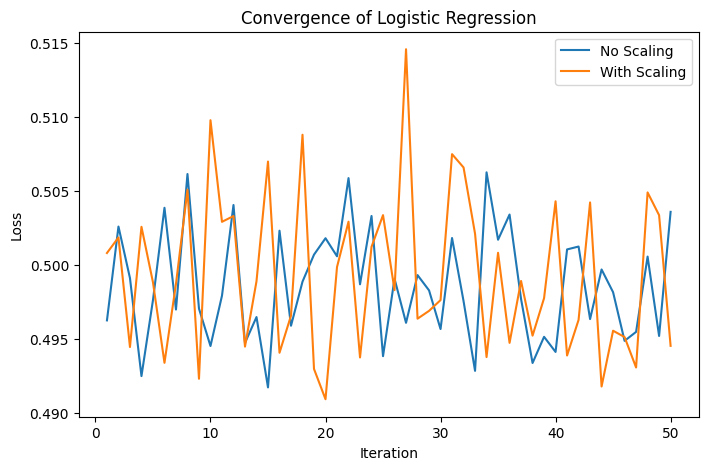

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Generate sample data
X, y = make_classification(n_samples=50000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize models
max_iter = 50
lr_no_scale = LogisticRegression(solver='saga', max_iter=1, warm_start=True)
lr_scaled = LogisticRegression(solver='saga', max_iter=1, warm_start=True)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 3. Track loss
loss_no_scale = []
loss_scaled = []

for i in range(max_iter):
    lr_no_scale.fit(X_train, y_train)
    loss_no_scale.append(lr_no_scale.loss_curve_[-1] if hasattr(lr_no_scale, 'loss_curve_') else lr_no_scale.predict_proba(X_train)[:,1].mean())
    
    lr_scaled.fit(X_train_scaled, y_train)
    loss_scaled.append(lr_scaled.loss_curve_[-1] if hasattr(lr_scaled, 'loss_curve_') else lr_scaled.predict_proba(X_train_scaled)[:,1].mean())

# 4. Plot
plt.figure(figsize=(8,5))
plt.plot(range(1,max_iter+1), loss_no_scale, label="No Scaling")
plt.plot(range(1,max_iter+1), loss_scaled, label="With Scaling")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Convergence of Logistic Regression")
plt.legend()
plt.show()